In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load customer dataset

data = pd.read_csv("WA_FnUseC_TelcoCustomerChurn.csv")

# Convert TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(
    data["TotalCharges"],
    errors="coerce"
)

# Remove rows with missing TotalCharges
data = data.dropna(subset=["TotalCharges"])

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)

Dataset loaded successfully!
Dataset shape: (7032, 21)


In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select the same features used in Day 30
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X_cluster = data[features].copy()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Use the optimized K from Day 30
k_values = range(2, 11)

silhouette_scores = []

from sklearn.metrics import silhouette_score

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

best_k = list(k_values)[np.argmax(silhouette_scores)]

print("Selected K:", best_k)

# Final clustering
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

data["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster counts:")
print(data["Cluster"].value_counts().sort_index())

Selected K: 2

Cluster counts:
Cluster
0    2360
1    4672
Name: count, dtype: int64


In [4]:
# Analyze each customer cluster

persona_summary = data.groupby("Cluster")[features].mean().round(2)

persona_summary["Customer Count"] = (
    data["Cluster"].value_counts()
    .sort_index()
)

print("Customer Persona Summary")
print("=" * 50)
print(persona_summary)

Customer Persona Summary
         tenure  MonthlyCharges  TotalCharges  Customer Count
Cluster                                                      
0         56.87           89.76       5084.99            2360
1         20.07           52.19        868.07            4672


In [5]:
# Detailed cluster statistics

detailed_summary = data.groupby("Cluster")[features].agg(
    ["mean", "median", "min", "max"]
).round(2)

print("Detailed Cluster Analysis")
print("=" * 50)
print(detailed_summary)

Detailed Cluster Analysis
        tenure                MonthlyCharges                        \
          mean median min max           mean median    min     max   
Cluster                                                              
0        56.87   60.0  21  72          89.76  92.93  35.75  118.75   
1        20.07   14.0   1  72          52.19  50.82  18.25  112.95   

        TotalCharges                            
                mean   median     min      max  
Cluster                                         
0            5084.99  4914.05  2317.1  8684.80  
1             868.07   673.90    18.8  2924.05  


In [6]:
# Compare cluster averages

cluster_means = data.groupby("Cluster")[features].mean()

print("Cluster Average Comparison")
print("=" * 50)

for cluster in cluster_means.index:
    print(f"\nCluster {cluster}")
    print(f"Average Tenure: {cluster_means.loc[cluster, 'tenure']:.2f} months")
    print(f"Average Monthly Charges: ${cluster_means.loc[cluster, 'MonthlyCharges']:.2f}")
    print(f"Average Total Charges: ${cluster_means.loc[cluster, 'TotalCharges']:.2f}")

Cluster Average Comparison

Cluster 0
Average Tenure: 56.87 months
Average Monthly Charges: $89.76
Average Total Charges: $5084.99

Cluster 1
Average Tenure: 20.07 months
Average Monthly Charges: $52.19
Average Total Charges: $868.07


In [7]:
# Assign business-friendly persona names

persona_mapping = {
    0: "Loyal High-Value Customers",
    1: "New/Low-Value Customers"
}

data["Persona"] = data["Cluster"].map(persona_mapping)

print("Persona names assigned successfully!")
print(data[["Cluster", "Persona"]].drop_duplicates().sort_values("Cluster"))

Persona names assigned successfully!
   Cluster                     Persona
8        0  Loyal High-Value Customers
0        1     New/Low-Value Customers


In [8]:
# Create final persona summary table

final_persona_summary = (
    data.groupby(["Cluster", "Persona"])[features]
    .mean()
    .round(2)
)

final_persona_summary["Customer Count"] = (
    data.groupby(["Cluster", "Persona"]).size()
)

print("FINAL CUSTOMER PERSONA SUMMARY")
print("=" * 60)
print(final_persona_summary)

FINAL CUSTOMER PERSONA SUMMARY
                                    tenure  MonthlyCharges  TotalCharges  \
Cluster Persona                                                            
0       Loyal High-Value Customers   56.87           89.76       5084.99   
1       New/Low-Value Customers      20.07           52.19        868.07   

                                    Customer Count  
Cluster Persona                                     
0       Loyal High-Value Customers            2360  
1       New/Low-Value Customers               4672  


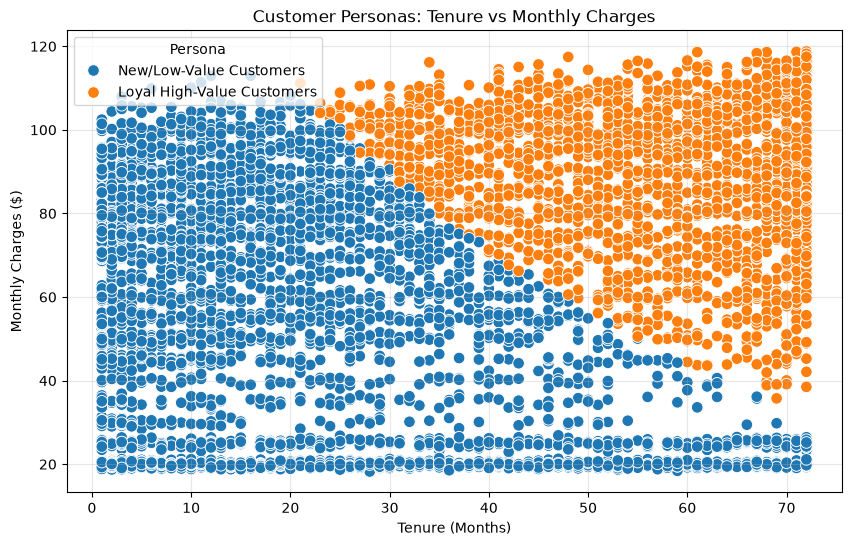

In [9]:
# Visualize persona spending and tenure patterns

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=data,
    x="tenure",
    y="MonthlyCharges",
    hue="Persona",
    s=70
)

plt.title("Customer Personas: Tenure vs Monthly Charges")
plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges ($)")
plt.legend(title="Persona")
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Compare average spending across personas

spending_summary = data.groupby("Persona")[["MonthlyCharges", "TotalCharges"]].mean().round(2)

print("Average Spending by Persona")
print("=" * 50)
print(spending_summary)

Average Spending by Persona
                            MonthlyCharges  TotalCharges
Persona                                                 
Loyal High-Value Customers           89.76       5084.99
New/Low-Value Customers              52.19        868.07


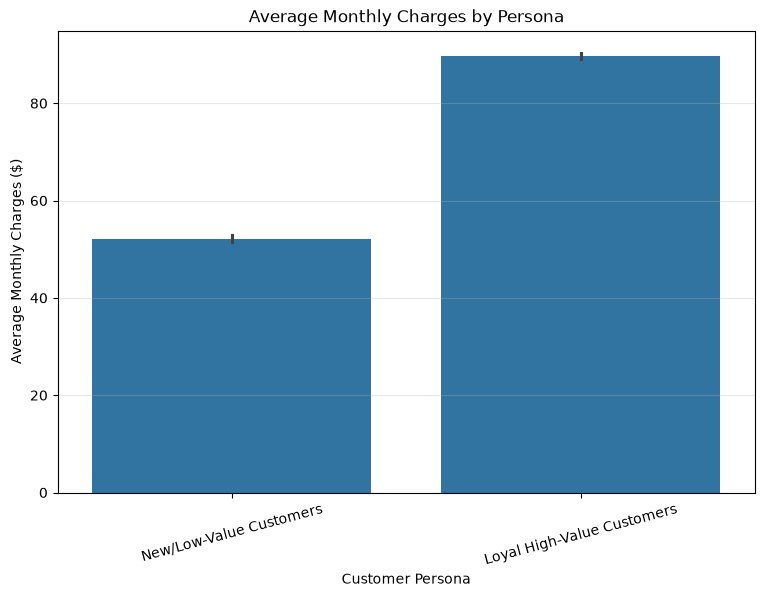

In [11]:
# Bar chart for average monthly charges

plt.figure(figsize=(9, 6))

sns.barplot(
    data=data,
    x="Persona",
    y="MonthlyCharges",
    estimator="mean"
)

plt.title("Average Monthly Charges by Persona")
plt.xlabel("Customer Persona")
plt.ylabel("Average Monthly Charges ($)")
plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.3)
plt.show()

In [12]:
# Business strategy recommendations for each persona

strategies = {
    "Loyal High-Value Customers": [
        "Offer loyalty rewards and exclusive benefits.",
        "Provide personalized offers based on their spending.",
        "Focus on retention and long-term relationship building."
    ],
    
    "New/Low-Value Customers": [
        "Provide onboarding offers to encourage continued usage.",
        "Use targeted promotions to increase engagement and spending.",
        "Monitor early customer behavior to identify retention opportunities."
    ]
}

for persona, recommendations in strategies.items():
    print("\n" + "=" * 60)
    print(persona)
    print("=" * 60)
    
    for i, recommendation in enumerate(recommendations, 1):
        print(f"{i}. {recommendation}")


Loyal High-Value Customers
1. Offer loyalty rewards and exclusive benefits.
2. Provide personalized offers based on their spending.
3. Focus on retention and long-term relationship building.

New/Low-Value Customers
1. Provide onboarding offers to encourage continued usage.
2. Use targeted promotions to increase engagement and spending.
3. Monitor early customer behavior to identify retention opportunities.


In [13]:
# Save persona summary as CSV

final_persona_summary.to_csv("customer_persona_report.csv")

print("Customer persona report saved successfully!")

Customer persona report saved successfully!


In [14]:
# Save business strategy recommendations

with open("business_strategy_recommendations.txt", "w") as file:
    for persona, recommendations in strategies.items():
        file.write(f"{persona}\n")
        file.write("=" * 50 + "\n")
        
        for i, recommendation in enumerate(recommendations, 1):
            file.write(f"{i}. {recommendation}\n")
        
        file.write("\n")

print("Business strategy recommendations saved successfully!")

Business strategy recommendations saved successfully!
